In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Load GBD
gbd = pd.read_csv(
    "../data/raw/IHME-GBD_2023_DATA-54ccbeed-1/IHME-GBD_2023_DATA-54ccbeed-1.csv"
)

# Load GDP
gdp_raw = pd.read_csv(
    "../data/raw/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_121708/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_121708.csv",
    skiprows=4
)

# GDP wide -> long, keep 2021 only
gdp_long = gdp_raw.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=["2021"],
    var_name="year",
    value_name="gdp_per_capita_ppp"
).dropna(subset=["gdp_per_capita_ppp"])

# GBD: filter to 2021, Both sexes, national-level only
wb_names = set(gdp_raw["Country Name"].dropna())
exclude = ["WB", "WHO", "Global", "World", "Region", "SDI", "Income", "Asia",
           "Africa", "Europe", "America", "Latin", "Oceania", "Caribbean", "Saharan"]
mask = ~gbd["location_name"].str.contains("|".join(exclude), na=False)
gbd_2021 = gbd[
    mask &
    (gbd["year"] == 2021) &
    (gbd["sex_name"] == "Both") &
    (gbd["location_name"].isin(wb_names))
].copy()

# Merge GBD + GDP
merged = gbd_2021.merge(
    gdp_long[["Country Name", "Country Code", "gdp_per_capita_ppp"]],
    left_on="location_name",
    right_on="Country Name",
    how="inner"
)

print("Merged shape:", merged.shape)
print("Countries:", merged["location_name"].nunique())
merged[["location_name", "val", "gdp_per_capita_ppp"]].head(10)

Merged shape: (166, 21)
Countries: 164


,location_name,val,gdp_per_capita_ppp
0,Thailand,34.472342,20242.770004
1,Philippines,15.952341,8857.789951
2,Timor-Leste,12.331008,6825.045886
3,Indonesia,20.391509,12757.074644
4,Viet Nam,19.874778,12048.901994
5,Kiribati,14.896644,3020.493999
6,Cambodia,15.083798,6225.532655
7,Samoa,20.292943,6350.114284
8,Maldives,20.047814,19052.622490
9,Albania,18.222472,18212.870247


R²          = 0.386
Intercept   = -53.00
Coefficient = 7.44


C:\code\gbd-gout-equity\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


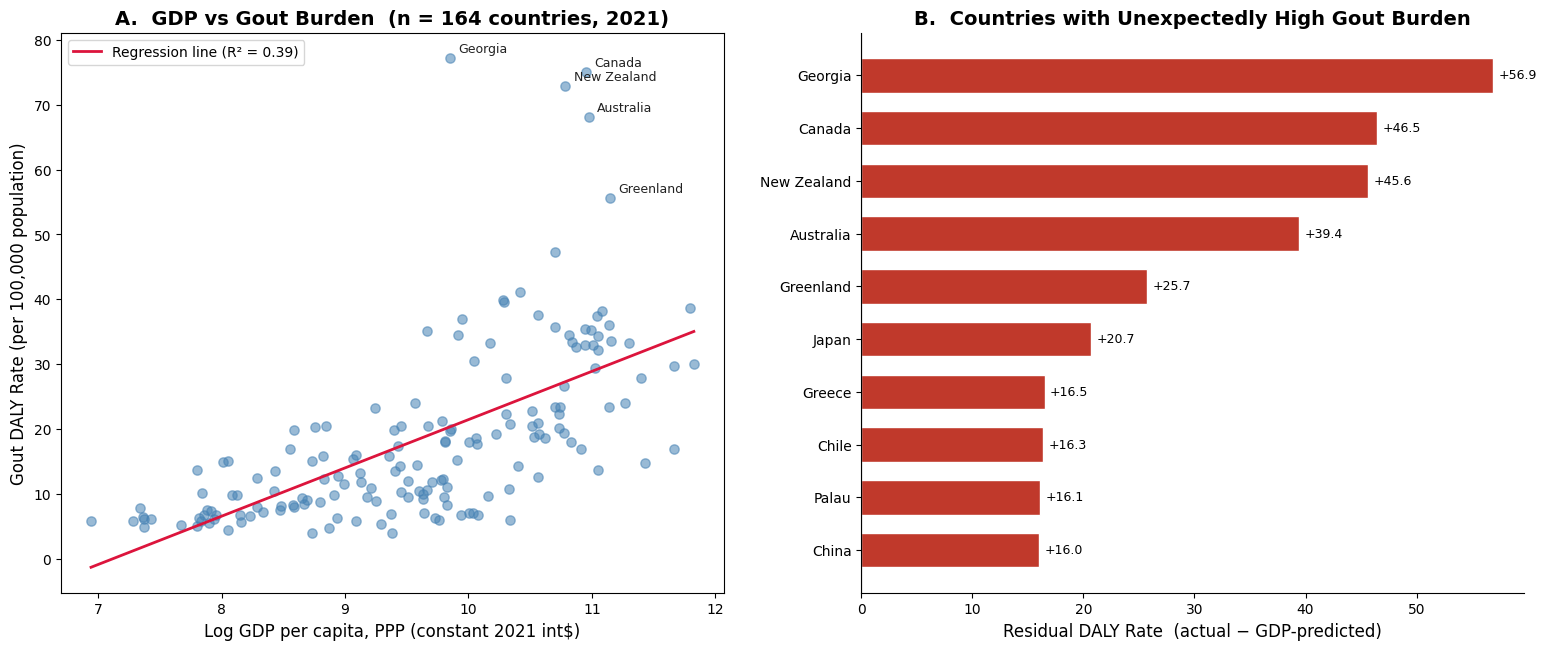

Saved: figures/fig4_dual_panel.png


In [2]:
# ── Regression ────────────────────────────────────────────────────────────────
merged["log_gdp"] = np.log(merged["gdp_per_capita_ppp"])

X = merged[["log_gdp"]]
y = merged["val"]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)
merged["predicted"] = model.predict(X)
merged["residual"]  = merged["val"] - merged["predicted"]

print(f"R²          = {r2:.3f}")
print(f"Intercept   = {model.intercept_:.2f}")
print(f"Coefficient = {model.coef_[0]:.2f}")

# ── Shared style constants ─────────────────────────────────────────────────────
TITLE_SIZE  = 14
LABEL_SIZE  = 12
TICK_SIZE   = 10
ANNOT_SIZE  = 9

# ── Fig 4: dual panel (scatter + residual bar) ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── Panel A: scatter + regression line ────────────────────────────────────────
ax1.scatter(merged["log_gdp"], merged["val"],
            alpha=0.55, color="steelblue", s=45, zorder=2)

x_line = np.linspace(merged["log_gdp"].min(), merged["log_gdp"].max(), 300)
y_line = model.predict(x_line.reshape(-1, 1))
ax1.plot(x_line, y_line, color="crimson", linewidth=2,
         label=f"Regression line (R\u00b2 = {r2:.2f})")

top5 = merged.nlargest(5, "residual")
for _, row in top5.iterrows():
    ax1.annotate(
        row["location_name"],
        (row["log_gdp"], row["val"]),
        textcoords="offset points", xytext=(6, 4),
        fontsize=ANNOT_SIZE, color="#222222"
    )

ax1.set_xlabel("Log GDP per capita, PPP (constant 2021 int$)", fontsize=LABEL_SIZE)
ax1.set_ylabel("Gout DALY Rate (per 100,000 population)", fontsize=LABEL_SIZE)
ax1.set_title("A.  GDP vs Gout Burden  (n = 164 countries, 2021)",
              fontsize=TITLE_SIZE, fontweight="bold")
ax1.legend(fontsize=TICK_SIZE)
ax1.tick_params(labelsize=TICK_SIZE)

# ── Panel B: top 10 residual bar chart ────────────────────────────────────────
top10 = merged.nlargest(10, "residual").sort_values("residual")

bars = ax2.barh(top10["location_name"], top10["residual"],
                color="#c0392b", edgecolor="white", height=0.65)

for bar, val in zip(bars, top10["residual"]):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f"+{val:.1f}", va="center", fontsize=ANNOT_SIZE)

ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Residual DALY Rate  (actual \u2212 GDP-predicted)", fontsize=LABEL_SIZE)
ax2.set_title("B.  Countries with Unexpectedly High Gout Burden",
              fontsize=TITLE_SIZE, fontweight="bold")
ax2.tick_params(labelsize=TICK_SIZE)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig("../figures/fig4_dual_panel.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/fig4_dual_panel.png")

In [3]:
# Save merged DataFrame for use in 04-multimodal.ipynb
merged.to_csv("../data/processed/merged_gbd_gdp_2021.csv", index=False)
print("Saved: data/processed/merged_gbd_gdp_2021.csv")
print(merged[["location_name", "Country Code", "val", "gdp_per_capita_ppp",
              "log_gdp", "predicted", "residual"]].sort_values("residual", ascending=False).head(10).to_string(index=False))

Saved: data/processed/merged_gbd_gdp_2021.csv
location_name Country Code       val  gdp_per_capita_ppp   log_gdp  predicted  residual
      Georgia          GEO 77.167718        18915.653401  9.847745  20.314549 56.853169
       Canada          CAN 74.989477        56995.117678 10.950721  28.525939 46.463538
  New Zealand          NZL 72.894783        48248.717673 10.784125  27.285669 45.609114
    Australia          AUS 68.073227        58327.414684 10.973827  28.697962 39.375265
    Greenland          GRL 55.688923        69302.008879 11.146229  29.981452 25.707472
        Japan          JPN 47.325366        44355.348716 10.699989  26.659297 20.666068
       Greece          GRC 41.080024        33531.155112 10.420230  24.576564 16.503460
        Chile          CHL 39.864585        29089.850460 10.278145  23.518770 16.345815
        Palau          PLW 35.079874        15780.550116  9.666533  18.965472 16.114402
        China          CHN 37.039277        20843.297835  9.944788  21.037